# 20 The bare MG90 motor

Notebooks 02, 03 and 04 measured the motor constants of an SG90 inside its servo, through a gear
train, a pot and a board that has since been retired. Notebooks 17 and 18 used the MG90 on rev 2A,
but always with the gearbox on, so every reading there carries the gears and the output stop. This
notebook takes the MG90's motor out of the servo and measures it alone. There is no gearbox, no pot
and no load. The motor is taped to a ceramic plate and plugged into J4, the motor connector, of rev
2A board #1, and a handheld meter sits on its terminals in ohms the whole time.

The questions were:

1. What does the motor's terminal resistance read at rest, how much does it move from one rotor
   stop to the next, and does it relax after a drive?
2. What current does the free motor draw at 5.0 V, and why does it rise with duty?
3. What is the back-EMF constant $K_e$, and do the coast and the spin agree on it?
4. What is the winding inductance $L$, and can the firmware's duty ramp measure it?
5. What resistance does the motor show while it turns, against the one it shows at rest?
6. Where does it break away from rest, in volts, amps and torque?

If you are short on time, here is the whole answer up front:

- **Rest resistance has no single value on this motor.** Fifteen stops turned by hand before any
  running read 4.31 to 5.30 ohm, median 4.46. Twenty settles after the drives read 4.63 to 5.18,
  median 4.76. Both are skewed high (the maximum sits 0.84 and 0.42 ohm over the median, the minimum
  0.15 and 0.13 under it), which is the shape a contact that only adds resistance would give. But
  the bulk is 2 to 2.4% wide, so the pre-registered one-sided test calls neither set. The settles
  sit 0.30 ohm [0.20, 0.38] over the hand map, and every one of them falls inside its 60 s.
- **The no-load current rises with speed, and the coast says the drag does too.** 59.7 mA at 12% to
  79.7 at 40%, 22 counts of rise at 10 sigma and not a straight line in duty. One inertia, $J$ =
  7.71e-9 kg m$^2$ within 4.5%, turns each rung's drive current into exactly the torque the same
  rung's coast loses, so no drive-only loss term is needed. The rotor is still speeding up at the
  end of the 300 ms spins.
- **$K_e$ = 1.1723e-3 V s/rad, a standard error of 0.37%.** That is the coast route, the floating
  terminals' mean EMF over a whole number of counted ripple cycles, against the speed counted in the
  same samples. The spin route agrees to +0.45% +/- 0.61%.
- **The duty ramp does not measure $L$.** The fitted time constant grows with the fit window and the
  never-turning 8% cycles grow the same way, so the window holds a slow term that is not the
  inductance. The ramp route is withdrawn. The one identification burst run on the bare motor fits
  0.843 mH with an envelope time constant of 129 us, on two captures, and declined itself.
- **In rotation the motor shows 5.53 +/- 0.11 ohm, 0.88 over the rest floor.** The excess voltage
  grows with speed. Neither a current-proportional contact term nor a sampling-phase term in the
  current explains it alone.
- **Breakaway sits near half a volt.** On a 3.76 V rail the motor turned at 14% (0.524 V) on one seat
  and held at 15% (122 mA, 0.143 mN m) on another. Turning, it needs 0.061 to 0.082 mN m.

The data comes in one dataset, and a second part of the run at 5.0 and 7.4 V is described at the end
without estimators.

## Picking a rig

One dataset, `mg90-a__dev-v006-2A__dps__bare-motor`. The per-tick captures carry the `sense` block,
so the board is read off the data, and every capture is checked against it as it loads. The servo
entry is mg90-a because that is where the motor came from. Only two of its entries matter here, the
ripple order (6 commutation events per motor revolution, a parts count) and the registry's $K_e$
from notebook 09, which section 4 compares against.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares
from IPython.display import display

import oscnb
from oscnb import datasets, minduty, heating, meterlog as ml, staticsweep as ss

DS = datasets.load("mg90-a__dev-v006-2A__dps__bare-motor")
board = DS.board                     # identified from the char captures' own sense block
servo = DS.servo                     # mg90-a: the motor came out of this servo
rig = oscnb.Rig(board, servo).show()

FS = float(board.tick_hz)            # one TEL row per kernel tick, one PWM period per tick
Q15 = 32767.0                        # duty_q15 full scale
T_PWM = 1.0 / FS                     # the PWM period, 50 us
CPA = board.counts_per_a             # shunt counts per amp, from the board's parts
VPC = board.v_term_per_count         # terminal-difference volts per count (bias free)
EV_PER_REV = servo.measured["ripple_order_measured"].value   # 3-slot commutator: 6 ripple events per motor rev

CY = ss.cycles(DS)                   # the runner's cycle log, one row per cycle k
EXCLUDE = DS.decl["char"]["exclude_cycles"]                  # cycle 23, the J4 open
print(f"board {board.key}: {CPA:.2f} counts/A, {VPC * 1e3:.4f} mV per terminal count")
print(f"cycles logged {len(CY)}, with a capture {int(CY.captured.sum())}, failed sweeps {CY[CY.rc != 0].index.tolist()}, "
      f"excluded {EXCLUDE} ({DS.decl['char']['exclude_why']})")


def dist(x):
    # the five-number spread every rest-R table in this notebook uses
    x = np.sort(np.asarray(x, float))
    return dict(n=len(x), min=x.min(), p10=np.quantile(x, 0.1), median=np.median(x), p90=np.quantile(x, 0.9), max=x.max())


def boot_ci(x, stat=np.median, n=4000, seed=0, q=(0.025, 0.975)):
    # bootstrap: resample with replacement, take the statistic, read its 95% band and sd
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    s = np.array([stat(rng.choice(x, len(x))) for _ in range(n)])
    return float(np.quantile(s, q[0])), float(np.quantile(s, q[1])), float(np.std(s))

Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. Floors 64/93 ticks: the current at 3% with the settle gain on top (nb10 sec 8), the terminals from the grid ladder with tap B sampled 37 ticks before 

value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from                               % duty                  5.3333
                 voltage settled from                               % duty                  7.7500
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800

board dev-v006-2A: 1108.45 counts/A, 4.0283 mV per terminal count
cycles logged 100, with a capture 96, failed sweeps [8, 22, 28, 69], excluded [23] (J4 open: spin current 0.78 counts over the trough, no back-EMF in the coast)


## 1. The experiment

- **Procedure.** The bench driver ran 100 cycles of the same chain. A cycle is one
  `osc sweep --static-load` commit, which takes a duty schedule under the stall permit with no
  position loop and no seek, and streams the telemetry burst (TEL) at every 50 us kernel tick. At
  5.0 V the schedule is a 6% stalled pre-pulse for 300 ms, a spin at the cycle's duty for 300 ms,
  and a coast, both bridge legs off, for 500 ms. The meter then reads the rest resistance through a
  60 s settle with torque off. Directions alternate. The duty rises as a ramp, because the firmware
  slews the applied duty at 128 q15 (signed 16-bit fraction) per tick, and the drop to the coast is
  a single step. Part 1 is cycles 1 to 22 at 5.0 V and is what sections 2 to 6 analyse. Part 2b
  (cycles 24 to 100, 5.0 V then 7.4 V) came after a J4 open was found and fixed, and section 9
  describes it. Three side experiments use the same rig: a hand map of the rest resistance across
  rotor stops before any running, a breakaway ladder on a 3.76 V rail, and a two-duty stall test.
  **Thermal rule.** Bare-motor runs follow Aaron's bench safety rule, at most 30 s on, then at
  least 20 s off. It is a rule, not a result of this notebook. Every capture here keeps it by a wide
  margin, as the inventory below shows.
- **Model.** The winding is a resistance, an inductance and a speed voltage in series,

$$v = R i + L \frac{di}{dt} + K_e \omega$$

  with $v$ the terminal voltage, $i$ the current, $\omega$ the motor shaft speed in rad/s and $K_e$
  the **back-EMF constant**, the volts the turning rotor generates per rad/s (EMF is electromotive
  force, the generated voltage). In the coast the bridge is high impedance, $i = 0$, and the
  terminals read $K_e \omega$ directly. The rotor obeys

$$J \frac{d\omega}{dt} = K_t i - T_f(\omega)$$

  with $J$ the rotor's inertia, $T_f$ whatever drag it has, and $K_t$ the **torque constant**. In SI
  units $K_t = K_e$, newton metres per amp equal volts per rad/s, so the torques below come from
  $K_e$. A 3-slot commutator puts 6 ripple events per revolution on the current and the terminals,
  so the ripple frequency is $6 \omega / 2 \pi$.
- **Estimators.** Current is the shunt sample less the same tick's trough sample, through the
  board's counts per amp. Voltage is the applied duty times the terminals' ON level, the driven
  terminal difference. Speed is never a spectral peak, because the coast's line sweeps. It comes from
  counting ripple cycles, band-passing around the peak, finding the zero crossings and dividing
  whole cycles by their span (`oscnb.staticsweep.count_cycles`). The rest resistance is the median of
  the meter's last 10 s of each settle (`oscnb.meterlog.settle`). Each section names its own.
- **Validity envelope.** One bare MG90 motor, free, unloaded, at room temperature with nothing
  logging it, 5.0 V set on the supply, duties 5 to 40%, 300 ms spins reaching up to about 190 rev/s,
  currents 58 to 85 mA. The meter reads only at standstill.
- **Accuracy.** The meter is the only outside instrument, and it reads at rest. $K_e$ has no outside
  truth here, only two routes through different samples, plus the registry value from inside the
  servo. $L$ is compared with the identification's burst experiment, E8 (the high-rate shunt burst
  inside `osc ident`). Nothing graded the torques.

In [2]:
inv = (CY.assign(rail=CY.rail.map(lambda v: f"{v:.1f} V"), ok=CY.captured & ~CY.index.isin(EXCLUDE))
         .groupby(["part", "rail", "duty"]).agg(logged=("rc", "size"), usable=("ok", "sum"), failed=("rc", lambda r: int((r != 0).sum())))
         .unstack("duty", fill_value=0))
display(inv)
# the first running out of the servo, before any of the cycles: one 9 s pulse
tape = pd.read_csv(DS.path / "tape-test/tape.csv")
on = tape[tape.leg == "on"]
print(f"tape test: {on.t_unix.max() - on.t_unix.min():.1f} s on at {on.duty_applied_q15.max() / Q15 * 100:.0f}% duty, "
      f"rail {board.vsys_v(on.vbus_raw.mean()):.2f} V, mean current {(on.current - on.current_trough).mean() / CPA * 1e3:.0f} mA")
# every char drive's length, from the schedules: a stalled pre-pulse and a spin of 300 ms each
rails = CY[CY.captured].groupby("rail").pre_vbus_raw.median().map(board.vsys_v)
print("rail the board read before each cycle, median: " + ", ".join(f"{k:.1f} V set -> {v:.2f} V" for k, v in rails.items()))
drv = CY.steps.str.findall(r"(?:then:)?\d+@(\d+)").map(lambda v: sum(int(x) for x in v))
print(f"char drive time per cycle: {drv.min()} to {drv.max()} ms; settle between cycles about "
      f"{np.median(np.diff(CY.t_sweep0.dropna().to_numpy())):.0f} s start to start")

logged                usable                failed               
duty           5  8  12 20 30 40     5  8  12 20 30 40     5  8  12 20 30 40
part rail                                                                   
1    5.0 V      3  3  4  4  4  4      1  3  4  4  4  4      2  0  0  0  0  0
2    5.0 V      0  0  0  1  0  0      0  0  0  0  0  0      0  0  0  0  0  0
2b   5.0 V      7  5  4  3  4  4      7  4  4  3  4  4      0  1  0  0  0  0
     7.4 V      8  8  9  8  9  8      8  8  9  8  9  7      0  0  0  0  0  1

tape test: 9.0 s on at 40% duty, rail 7.07 V, mean current 94 mA
rail the board read before each cycle, median: 5.0 V set -> 4.76 V, 7.4 V set -> 7.14 V
char drive time per cycle: 300 to 600 ms; settle between cycles about 62 s start to start


**What you are looking at.** How many cycles each part logged per duty, how many left a usable
capture, and how many failed, then the first running of the motor out of the servo, the rail the
board read, and the drive time per cycle against the time between cycles.

Four sweeps failed and left no capture. Two were 5% reverse cycles in part 1, where the coast
segment came back with telemetry sequence holes on all three tries. The other two are in part 2b.
Cycle 23 is the J4 open. Its spin current read under a count over the trough, with no back-EMF in
the coast. It stays in the dataset and is excluded everywhere. Part 1 therefore has one usable 5%
cycle and four of each other duty, except three at 8%.

Each cycle drives for 0.3 to 0.6 s in about a minute, far inside the thermal rule. The 9 s tape test came first and is the longest the motor ran out of the servo.

## 2. Rest resistance across rotor stops

The meter reads the terminals with about a milliamp. That is the winding's copper plus the two
brush contacts, plus whatever the commutator segment under each brush adds at that rotor angle. So a
reading belongs to the rotor's stop, not to the motor. Two sets of stops are here. The hand map is
fifteen readings Aaron took 30 s after turning the shaft to a new stop by hand, before the motor had
ever run out of the servo. The char settles are the 20 usable part-1 cycles, each the median of the
last 10 s of a 60 s settle after the cycle's drive left the rotor wherever it stopped.

The pre-registered rule (bench note) calls a distribution **one-sided**, the contact only adds, if
the median sits within 1.5% of the tenth percentile (p10) and at least 15% of stops read more than
3% over it. It calls it **two-sided** if the median sits more than 1.5% over p10 and the upper half
spreads within a factor 2 of the lower. The bootstrap resamples each set with replacement 4000 times
for the median's 95% band.

In [3]:
HAND = pd.read_csv(DS.path / "hand-map/stops.csv").ohm.to_numpy()      # Aaron's 15 readings, 30 s after each stop
tm, vm = ml.read(DS.path / "char/dmm.csv")                             # part 1's meter log, ohms
P1 = CY[CY.part == "1"]
rows = []
for k, r in P1.iterrows():
    if r.t_off != r.t_off or r.t_off is None:
        continue
    s = ml.settle(tm, vm, r.t_off)        # first settled second, last 10 s of the 60 s settle, slope
    rows.append(dict(cycle=k, rc=r.rc, duty=r.duty, dir=r.dir, **s))
SET = pd.DataFrame(rows).dropna(subset=["rest"]).set_index("cycle")
GOOD = SET[SET.rc == 0]                    # the 20 cycles whose sweep landed (8 and 22 settled too)
pre = vm[(tm < P1.t_sweep0.min() - 60) & (vm > 1.0)]
print(f"meter before the first char drive: n {len(pre)}, median {np.median(pre):.3f}, {pre.min():.2f}..{pre.max():.2f} ohm")


def classify(x):
    # the rule pre-registered in the bench note, applied as written
    d = dist(x)
    lo = (d["median"] - d["p10"]) / d["p10"]
    share = float(np.mean(np.asarray(x) > 1.03 * d["p10"]))
    ratio = (d["p90"] - d["median"]) / (d["median"] - d["p10"])
    one = lo <= 0.015 and share >= 0.15
    two = lo > 0.015 and 0.5 <= ratio <= 2
    return dict(lo_pct=100 * lo, share_gt3pct=share, upper_over_lower=ratio,
                verdict="ONE-SIDED" if one else "TWO-SIDED" if two else "unclassified")


rows = []
for name, x in (("hand map, before any running", HAND), ("char, 60 s settles", GOOD.rest.to_numpy())):
    d, c = dist(x), classify(x)
    lo, hi, _ = boot_ci(x)
    rows.append({"set": name, **d, "median 95% lo": lo, "median 95% hi": hi, "(med-p10)/p10 %": c["lo_pct"],
                 "share > 1.03 p10": c["share_gt3pct"], "(p90-med)/(med-p10)": c["upper_over_lower"], "rule": c["verdict"],
                 "max - median": d["max"] - d["median"], "median - min": d["median"] - d["min"]})
REST = pd.DataFrame(rows).set_index("set")
display(REST.round(3))
print(f"worst hand-map stop over the hand map's p10: {(HAND.max() / np.quantile(HAND, .1) - 1) * 100:.0f}%")

meter before the first char drive: n 114, median 4.800, 4.80..4.84 ohm


,n,min,p10,median,p90,max,median 95% lo,median 95% hi,(med-p10)/p10 %,share > 1.03 p10,(p90-med)/(med-p10),rule,max - median,median - min
set,,,,,,,,,,,,,,
"hand map, before any running",15,4.31,4.370,4.46,4.696,5.30,4.41,4.530,2.059,0.333,2.622,unclassified,0.84,0.15
"char, 60 s settles",20,4.63,4.649,4.76,4.995,5.18,4.70,4.805,2.388,0.400,2.117,unclassified,0.42,0.13


worst hand-map stop over the hand map's p10: 21%


**What you are looking at.** The five-number spread of each set, the median's bootstrap band, and
the rule's three inputs and verdict, plus the two tail lengths.

- **Both sets are skewed high.** The highest stop sits 0.84 ohm over the hand map's median and the
  lowest 0.15 under it; for the settles, 0.42 against 0.13. That is the shape a contact term that
  only adds would give.
- **Neither passes the rule.** The bulk is 2.1 and 2.4% wide from p10 to the median, too wide for
  one-sided, and the upper spread is 2.6 and 2.1 times the lower, too long for two-sided. So the
  data does not say whether stop-to-stop scatter is a contact that only adds or a two-sided spread
  with a tail.
- **The meter read 4.80 ohm at the stop the rotor rested on before the first char drive.**

In [4]:
h, c = HAND, GOOD.rest.to_numpy()
rng = np.random.default_rng(1)
# bootstrap both sets independently: the shift of the median and of the p10
dm = [np.median(rng.choice(c, len(c))) - np.median(rng.choice(h, len(h))) for _ in range(4000)]
dp = [np.quantile(rng.choice(c, len(c)), .1) - np.quantile(rng.choice(h, len(h)), .1) for _ in range(4000)]
SHIFT = dict(med=np.median(c) - np.median(h), med_ci=np.quantile(dm, [.025, .975]),
             p10=np.quantile(c, .1) - np.quantile(h, .1), p10_ci=np.quantile(dp, [.025, .975]))
ALPHA_CU = 0.00393                            # copper's resistance slope near room, per K (notebook 17's handbook value)
print("shift char - hand: median %+.2f [%.2f, %.2f] ohm, p10 %+.2f [%.2f, %.2f] ohm (bootstrap 95%%)"
      % (SHIFT["med"], *SHIFT["med_ci"], SHIFT["p10"], *SHIFT["p10_ci"]))
print("as copper warming, the median shift is %.0f K" % ((np.median(c) / np.median(h) - 1) / ALPHA_CU))

# hold or decay within the 60 s settle, the pre-registered rule
p10 = np.quantile(GOOD.rest, .1)
g = GOOD.assign(excess0=GOOD.first_s - p10, fall=GOOD.first_s - GOOD.rest)
high = g[g.first_s > 1.03 * p10]
decayed = high.fall >= 0.5 * high.excess0
print(f"high stops (first second over 1.03 x p10 = {1.03 * p10:.3f}): {len(high)}; decayed by half their excess: "
      f"{int(decayed.sum())}; held: {int((~decayed).sum())}")
A = np.vstack([g.excess0, np.ones(len(g))]).T
coef, *_ = np.linalg.lstsq(A, g.fall, rcond=None)
res = g.fall - A @ coef
cov = res.var(ddof=2) * np.linalg.inv(A.T @ A)
FALL = dict(k=coef[0], k_se=np.sqrt(cov[0, 0]), c=coef[1], c_se=np.sqrt(cov[1, 1]))
print("drop over the 60 s settle = %.3f (se %.3f) x first-second excess + %.3f (se %.3f) ohm, n %d; every settle falls: %s"
      % (FALL["k"], FALL["k_se"], FALL["c"], FALL["c_se"], len(g), bool((g.fall > 0).all())))

shift char - hand: median +0.30 [0.20, 0.38] ohm, p10 +0.28 [0.22, 0.36] ohm (bootstrap 95%)
as copper warming, the median shift is 17 K
high stops (first second over 1.03 x p10 = 4.788): 14; decayed by half their excess: 1; held: 13
drop over the 60 s settle = 0.153 (se 0.018) x first-second excess + 0.051 (se 0.005) ohm, n 20; every settle falls: True


**The settles sit 0.30 ohm over the hand map.** The median moved +0.30 [0.20, 0.38] ohm and the p10
+0.28 [0.22, 0.36]. Read as copper warming that would be 17 K, and the drives here put almost
nothing into the winding, so heat is not a candidate anyone would pick. But the two sets are two
sessions with three things changed between them: the motor's first running, the orientation on the
plate, and hands on the shaft against tape on the can. And the pre-drive reading of 4.80 says the
shift was already there before the first char drive. So this is an observation, not a finding.

**Within a settle the reading falls and mostly holds.** Of the 14 stops whose first settled second
read more than 3% over p10, 13 kept more than half their excess through the 60 s; one decayed.
Every one of the 20 settles fell, by 0.051 +/- 0.005 ohm plus 0.153 +/- 0.018 times its
first-second excess. A fall that every stop shares and that grows with the excess is a relaxation of
something, not noise. Two candidates are alive: a contact film relaxing after the drive current
stopped, and a thermoelectric voltage at the brushes (a warm dissimilar-metal joint adds a few
microvolts to the meter's sense voltage, which reads as ohms). They predict different things when
the meter's leads swap: a film is symmetric, a thermoelectric voltage changes sign.

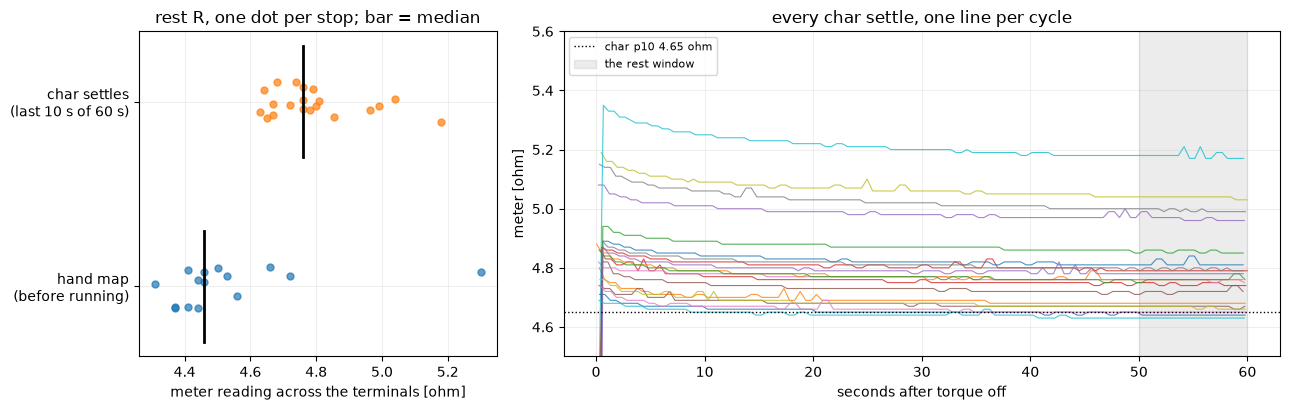

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw=dict(width_ratios=[1, 2]))
for y, (name, x) in enumerate((("hand map", HAND), ("char settles", GOOD.rest))):
    jit = np.random.default_rng(y).uniform(-0.12, 0.12, len(x))
    a1.plot(x, y + jit, "o", ms=5, alpha=0.7)
    a1.plot([np.median(x)] * 2, [y - 0.3, y + 0.3], "k-", lw=2)
a1.set_yticks([0, 1], ["hand map\n(before running)", "char settles\n(last 10 s of 60 s)"])
a1.set_xlabel("meter reading across the terminals [ohm]")
a1.set_title("rest R, one dot per stop; bar = median")
a1.grid(alpha=0.2)
for k, r in GOOD.iterrows():
    sel = (tm >= P1.t_off[k]) & (tm < P1.t_off[k] + 60) & (vm > 1.0)    # the settle, before the next drive's range changes
    a2.plot(tm[sel] - P1.t_off[k], vm[sel], lw=0.8, alpha=0.8)
a2.axhline(p10, color="k", ls=":", lw=1, label=f"char p10 {p10:.2f} ohm")
a2.set_ylim(4.5, 5.6)
a2.axvspan(50, 60, color="grey", alpha=0.15, label="the rest window")
a2.set_xlabel("seconds after torque off")
a2.set_ylabel("meter [ohm]")
a2.set_title("every char settle, one line per cycle")
a2.legend(fontsize=8)
a2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**What you are looking at.** Left, every rest reading of both sets, one dot per stop, the bar at
the median. Right, the meter through each char settle, time from torque off, the grey band the
window the rest value is taken from, the dotted line the settles' p10.

**Why this motor has no absolute R.** The resistance a brushed DC motor shows at its terminals
depends on where the rotor stopped, by 2% in the bulk and by 21% at the worst hand-map stop. It
also moved 0.3 ohm between two sessions with nothing obvious changed, and it relaxes for a minute
after a drive. A single meter reading, or a single firmware anchor at one seat, is one sample of
that spread. A winding thermometer that takes R as a ratio to its own reference, at the same seat
and in the same state, is immune to the spread. Anything that treats one R reading as the motor's
R is not.

## 3. No-load current at 5.0 V

Every part-1 cycle goes through the same per-cycle reduction, used by this section and the next
three:

- **Stall**, the last 200 ms of the 6% pre-pulse: current over the trough, applied duty.
- **Spin**, the last 100 ms: current over the trough, the applied duty $D$, and the terminals' ON
  level $V_{on}$. Their product $D V_{on}$ is the drive voltage. The spin's speed is the ripple
  counted in the current over the last 150 ms.
- **Coast**, from the first tick whose applied duty is 0. A cycle turned if the terminal EMF 0.1 to
  1 ms in is at least 0.05 V. $E_0$ is a line through the one-ripple boxcar of the EMF over 1 to 11
  ms, extrapolated back to the duty-0 tick. The coast's speed is counted in the EMF itself over the
  same 1 to 11 ms. A viscous plus Coulomb fit, $dE/dt = -a - E/\tau$, through the whole coast gives
  the drag at any EMF. A plain exponential fitted to the spin's last 200 ms gives where its current
  is heading.

In [6]:
L_IN_SERVO = float(heating.WAVE.search((DS.path / "ref/in-servo-ident-report.txt").read_text())[3]) * 1e-3   # H


def spin_row(k):
    """One part-1 cycle through the note's estimators: the stalled 6%, the spin's
    steady window, the coast's back-EMF and its counted ripple speed."""
    r = CY.loc[k]
    d = r.dir
    seg = ss.segments(ss.frame(DS, k), r.steps)
    st, sp, co = seg["stall"], seg["spin"], seg["coast"]
    row = dict(cycle=k, duty=r.duty, dir=d)
    # stalled 6%, last 200 ms: current over the same tick's trough sample
    w = st.iloc[-4000:]
    row.update(st_i_counts=(w.current_raw - w.current_trough).mean(), st_D=(w.duty_q15 * d / Q15).mean())
    # spin, last 100 ms: current over the trough, applied duty, and the driven ON level of the taps
    w = sp.iloc[-2000:]
    i = (w.current_raw - w.current_trough).to_numpy(float)
    D = (w.duty_q15 * d / Q15).to_numpy(float)
    von = ((w.vmotor_a - w.vmotor_b) * d).to_numpy(float) * VPC
    row.update(i_counts=i.mean(), i_A=i.mean() / CPA, D=D.mean(), Von=von.mean(), V_drive=(D * von).mean())
    # spin speed: ripple cycles counted in the current over the last 150 ms, seeded by the spectral line
    xs = (sp.current_raw - sp.current_trough).to_numpy(float)[-3000:]
    f_pk, _ = ss.line_freq(xs)
    row["f_spin"] = ss.count_cycles(xs, f_pk)[0]
    # coast: from the first tick whose applied duty is 0 (bridge Hi-Z, no current)
    z = np.flatnonzero(co.duty_q15.to_numpy() == 0)
    if not len(z):
        return row
    E = ((co.vmotor_a - co.vmotor_b) * d).to_numpy(float)[z[0]:] * VPC
    row["E_first_ms"] = E[2:20].mean()
    row["turn"] = bool(row["E_first_ms"] >= 0.05)       # a rotor that did not turn leaves no back-EMF
    if not row["turn"]:
        return row
    t = np.arange(len(E)) / FS
    f_c0, _ = ss.line_freq(E[20:220])                    # the coast ripple's line, 1 to 11 ms
    nbox = max(int(round(FS / f_c0)), 1)
    Es = np.convolve(E, np.ones(nbox) / nbox, mode="same")   # one-ripple boxcar
    p = np.polyfit(t[20:220], Es[20:220], 1)               # line through 1-11 ms, extrapolated to the duty-0 tick
    row.update(E0_lin=np.polyval(p, 0.0), dEdt=p[0])
    # same-window Ke: the mean E over a whole number of ripple cycles, counted in E itself
    f_cw, b0, b1, ncw = ss.count_cycles(E[20:220], f_c0)
    row.update(f_coast=f_cw, coast_ncyc=ncw, E_win=E[20 + b0:20 + b1].mean() if ncw else np.nan)   # no whole cycle, no mean
    # viscous + Coulomb fit of the whole coast: dE/dt = -a - E / tau
    zc = np.flatnonzero(Es[20:] < 0.03 * row["E0_lin"])
    stop = 20 + (zc[0] if len(zc) else len(E) - 20)
    vc = lambda x, e0, tau, a: np.maximum((e0 + a * tau) * np.exp(-x / tau) - a * tau, 0.0)
    try:
        q, _ = curve_fit(vc, t[20:stop], E[20:stop], p0=[row["E0_lin"], 0.2, 8.0], bounds=([0, 1e-3, 0], [5, 50, 100]))
        dec = lambda e: q[2] + e / q[1]
        row.update(dec_E0=dec(row["E0_lin"]), dec_ratio=dec(row["E0_lin"]) / dec(0.25))
    except Exception:
        pass
    # the spin's tail: an exponential approach fitted 100-300 ms, its asymptote
    xs2 = (sp.current_raw - sp.current_trough).to_numpy(float)
    tb = np.arange(len(xs2)) / FS
    try:
        p2, _ = curve_fit(lambda x, a, A, tau: a + A * np.exp(-(x - 0.1) / tau), tb[2000:], xs2[2000:],
                          p0=[xs2[-500:].mean(), 10, 0.1], bounds=([0, -100, 0.01], [400, 400, 2]))
        row.update(i_inf=p2[0], tail_tau=p2[2])
    except Exception:
        pass
    return row


P1OK = [k for k in CY.index if CY.loc[k, "part"] == "1" and CY.loc[k, "captured"]]
SPIN = pd.DataFrame([spin_row(k) for k in P1OK]).set_index("cycle")
SPIN["turn"] = SPIN.turn.fillna(False).astype(bool)
SPIN["w_spin"] = 2 * np.pi * SPIN.f_spin / EV_PER_REV        # rad/s at the motor shaft
SPIN["w_coast"] = 2 * np.pi * SPIN.f_coast / EV_PER_REV
SPIN["Ke_spin"] = SPIN.E0_lin / SPIN.w_spin                  # EMF at the cut over the drive's speed
SPIN["Ke_coast"] = SPIN.E_win / SPIN.w_coast                 # same window, same channel, I = 0
print(f"{len(SPIN)} part-1 cycles, {int(SPIN.turn.sum())} turned")
display(SPIN[["duty", "dir", "i_counts", "D", "Von", "E_first_ms", "turn", "E0_lin", "f_spin", "f_coast", "coast_ncyc",
              "Ke_spin", "Ke_coast"]].round(5))

20 part-1 cycles, 16 turned


,duty,dir,i_counts,D,Von,E_first_ms,turn,E0_lin,f_spin,f_coast,coast_ncyc,Ke_spin,Ke_coast
cycle,,,,,,,,,,,,,
1,20,1,76.5355,0.19999,4.68299,0.53017,True,0.52560,442.88742,373.42868,1.0,0.00113,0.00120
2,40,-1,94.5935,0.39998,4.66168,1.36403,True,1.34646,1083.34482,1037.25861,7.0,0.00119,0.00116
3,30,1,86.8850,0.30000,4.67340,0.98716,True,0.93630,749.23069,698.12965,4.0,0.00119,0.00118
4,30,-1,87.4715,0.30000,4.67171,0.93077,True,0.96514,784.81274,729.94841,5.0,0.00117,0.00116
5,40,1,87.6530,0.39998,4.67061,1.34635,True,1.39620,1125.42613,1075.44997,7.0,0.00118,0.00117
6,20,-1,76.3040,0.19999,4.68356,0.55278,True,0.59026,473.63666,426.64418,1.0,0.00119,0.00116
7,5,1,64.6610,0.04999,2.57833,-0.00246,False,NaN,778.18267,NaN,NaN,NaN,NaN
9,12,1,66.4570,0.12000,4.69662,0.21216,True,0.20417,205.74782,NaN,0.0,0.00095,NaN
10,8,-1,87.0130,0.07999,4.67953,-0.02327,False,NaN,804.25150,NaN,NaN,NaN,NaN


**What you are looking at.** One row per usable part-1 cycle. The 5% and the three 8% cycles left no
back-EMF, so they never turned. The 12% coasts are too slow to hold a whole counted ripple cycle in
1 to 11 ms, so they have no coast speed. The spin count still works there, at 206 to 228 Hz.

Per rung, the mean current and its standard error (se) across cycles. Then for the turning rungs
the coast's drag. The ratio is the coast's deceleration at the rung's own $E_0$ over its
deceleration at 0.25 V, the 12% rung's speed. $J$ is the inertia that makes the drive current
exactly the torque the coast loses at the same speed,

$$J = \frac{K_e^2 I}{\left. dE/dt \right|_{E_0}}$$

because the drive current's torque $K_t I$ balances the drag at steady speed, and the coast loses
$J d\omega/dt = (J / K_e) dE/dt$ to that same drag.

In [7]:
g = SPIN.groupby("duty").agg(n=("i_counts", "size"), turned=("turn", "sum"), i=("i_counts", "mean"), sd=("i_counts", "std"),
                             E0=("E0_lin", "mean"))
g["se"] = g.sd / np.sqrt(g.n)
g["mA"], g["mA_se"] = g.i / CPA * 1e3, g.se / CPA * 1e3
KE = SPIN.Ke_coast.median()                                    # section 4's Ke, used here only as Kt
tg = SPIN[SPIN.turn].groupby("duty").agg(dec_E0=("dec_E0", "mean"), dec_ratio=("dec_ratio", "mean"),
                                        dec_ratio_sd=("dec_ratio", "std"), i_inf=("i_inf", "mean"), tail_tau_ms=("tail_tau", lambda x: 1e3 * x.median()))
# J that makes the drive current exactly the torque the coast loses at the rung's own speed
tg["J_kgm2"] = KE ** 2 * (g.loc[tg.index, "mA"] / 1e3) / tg.dec_E0
tg["i_inf_minus_i_mA"] = (tg.i_inf - g.loc[tg.index, "i"]) / CPA * 1e3
NOLOAD = g.join(tg)
NOLOAD["J 1e-9 kg m^2"] = NOLOAD.J_kgm2 * 1e9
display(NOLOAD[["n", "turned", "mA", "mA_se", "E0", "dec_ratio", "dec_ratio_sd", "J 1e-9 kg m^2", "i_inf_minus_i_mA", "tail_tau_ms"]].round(3))
spin = g[(g.turned == g.n) & (g.index >= 12)]
x, y, se = spin.index.values.astype(float), spin.i.values, spin.se.values
W = 1 / se ** 2
A = np.vstack([np.ones_like(x), x]).T
cov = np.linalg.inv(A.T @ (A * W[:, None]))
coef = cov @ (A.T @ (W * y))
CHI2 = float(np.sum((y - A @ coef) ** 2 * W))
RISE = (spin.loc[40].i - spin.loc[12].i, np.hypot(spin.loc[40].se, spin.loc[12].se))
J = tg.J_kgm2
print(f"rise 12% -> 40%: {RISE[0]:.1f} +/- {RISE[1]:.1f} counts; a line in duty: chi2 {CHI2:.1f} on {len(x) - 2} dof, "
      f"residuals/se {np.round((y - A @ coef) / se, 2).tolist()}")
print(f"one inertia across the turning rungs: J {J.mean():.2e} kg m^2, spread {J.std() / J.mean() * 100:.1f}% (sd/mean)")
L_bound = {}
for duty in spin.index:
    s = SPIN[SPIN.duty == duty]
    # the current's slope during ON, from the voltage across L, and what 1 us of sample offset moves
    L_bound[duty] = (s.Von - s.E0_lin - round(p10, 2) * s.i_A).mean() / L_IN_SERVO * 1e-6 * 1e3   # mA per us
print("ON-current slope, mA per us of sample offset:", {int(k): round(float(v), 2) for k, v in L_bound.items()},
      f"-> the 12-40% rise moves {L_bound[12] - L_bound[40]:.2f} mA per us of a constant offset (L {L_IN_SERVO * 1e3:.3f} mH)")
print(f"to make the whole {RISE[0] / CPA * 1e3:.1f} mA rise, a constant offset would need {RISE[0] / CPA * 1e3 / (L_bound[12] - L_bound[40]):.0f} us "
      f"of a {T_PWM * 1e6:.0f} us period")

,n,turned,mA,mA_se,E0,dec_ratio,dec_ratio_sd,J 1e-9 kg m^2,i_inf_minus_i_mA,tail_tau_ms
duty,,,,,,,,,,
5,1,0,58.335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3,0,80.633,1.524,NaN,NaN,NaN,NaN,NaN,NaN
12,4,4,59.746,0.293,0.246,0.980,0.074,7.254,-2.429,72.799
20,4,4,68.376,0.331,0.577,1.191,0.080,8.065,5.544,76.021
30,4,4,76.753,1.110,0.975,1.369,0.028,7.850,-3.760,167.113
40,4,4,79.653,1.954,1.392,1.470,0.047,7.670,-5.123,105.656


rise 12% -> 40%: 22.1 +/- 2.2 counts; a line in duty: chi2 18.7 on 2 dof, residuals/se [-1.37, 2.21, -0.24, -3.45]
one inertia across the turning rungs: J 7.71e-09 kg m^2, spread 4.5% (sd/mean)
ON-current slope, mA per us of sample offset: {12: 5.51, 20: 5.01, 30: 4.42, 40: 3.84} -> the 12-40% rise moves 1.67 mA per us of a constant offset (L 0.757 mH)
to make the whole 19.9 mA rise, a constant offset would need 12 us of a 50 us period


**What you are looking at.** Per duty, the cycles and how many turned, the mean current in mA with
its se, the EMF at the cut, the coast's drag ratio, the implied inertia, the spin tail's asymptote
less the window's current, and the tail's time constant.

- **The current rises with speed, and not in a line.** 59.7 mA at 12% to 79.7 at 40%, a rise of
  22.1 +/- 2.2 counts. A straight line in duty misses by -1.4, +2.2, -0.2 and -3.5 se, a chi-squared
  of 18.7 on 2 degrees of freedom, so the rise is concave. The 8% cycles held at 80.6 mA, more than
  the free 12% draws, because a locked rotor has no back-EMF to oppose the drive.
- **The coast's drag rises with speed too, and one inertia ties them.** At 40% the coast decelerates
  1.47 times as hard as at 12%'s speed. The implied $J$ comes out at 7.71e-9 kg m$^2$ with a 4.5%
  spread across the four rungs. If the drive current carried a loss the coast does not have, iron
  loss under drive or a drive-only brush term, $J$ would climb with duty. It does not, so the
  current's rise is the same drag the free coast shows, and no drive-only term is needed. The data
  leaves open what the drag is, friction rising with speed, iron loss in the rotor, or both. They
  separate with the magnet can off: a spin-down with no field has no iron loss.
- **The sample's phase in the ripple is bounded.** The current ramps during each ON window at 5.5
  mA per us at 12% and 3.8 at 40% (the ON voltage across the in-servo identification's 0.757 mH). A
  constant offset of the sample in that ramp would move the 12-to-40 rise by only 1.67 mA per us of
  offset. The whole 19.9 mA rise would need a constant offset of 12 us of the 50 us period.

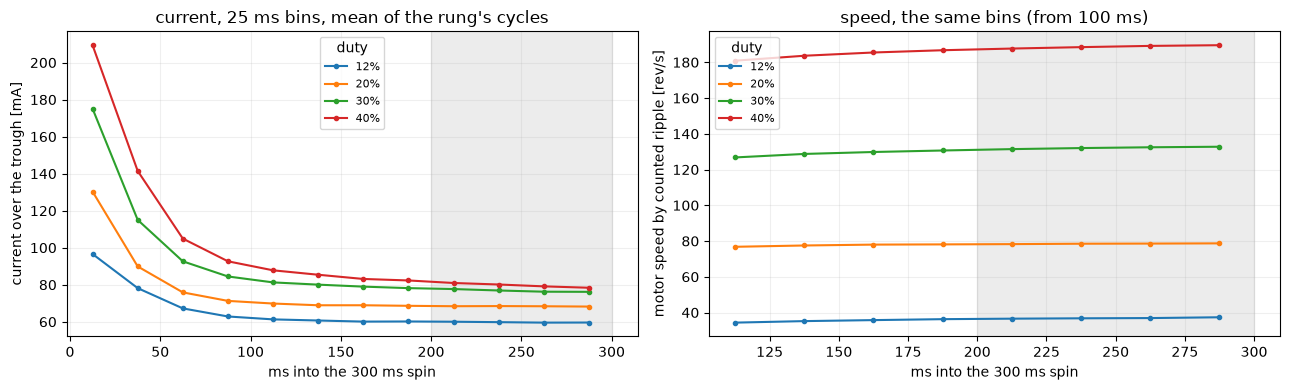

30%: current 77.7 -> 76.2 mA and speed 131.4 -> 132.8 rev/s across the last 100 ms
40%: current 81.0 -> 78.4 mA and speed 187.7 -> 189.6 rev/s across the last 100 ms


In [8]:
rows = []
for k in SPIN[SPIN.duty >= 12].index:
    sp = ss.segments(ss.frame(DS, k), CY.loc[k, "steps"])["spin"]
    x = (sp.current_raw - sp.current_trough).to_numpy(float)
    f_pk, _ = ss.line_freq(x[-3000:])
    for b in range(12):                                         # 25 ms bins over the 300 ms spin
        f = ss.count_cycles(x[max(b * 500 - 200, 0):(b + 1) * 500 + 200], f_pk, frac=0.5)[0] if b >= 4 else np.nan
        rows.append(dict(cycle=k, duty=CY.loc[k, "duty"], bin_ms=25 * b + 12.5, mA=x[b * 500:(b + 1) * 500].mean() / CPA * 1e3,
                         rev_s=f / EV_PER_REV))
SU = pd.DataFrame(rows)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for duty, gg in SU.groupby("duty"):
    m = gg.groupby("bin_ms").mean(numeric_only=True)
    a1.plot(m.index, m.mA, "o-", ms=3, label=f"{duty}%")
    a2.plot(m.index, m.rev_s, "o-", ms=3, label=f"{duty}%")
for a in (a1, a2):
    a.axvspan(200, 300, color="grey", alpha=0.15)
    a.set_xlabel("ms into the 300 ms spin")
    a.grid(alpha=0.2)
    a.legend(title="duty", fontsize=8)
a1.set_ylabel("current over the trough [mA]")
a2.set_ylabel("motor speed by counted ripple [rev/s]")
a1.set_title("current, 25 ms bins, mean of the rung's cycles")
a2.set_title("speed, the same bins (from 100 ms)")
plt.tight_layout()
plt.show()
last = SU[SU.bin_ms >= 200].groupby(["duty", "bin_ms"]).mean(numeric_only=True)
for duty in (30, 40):
    v = last.loc[duty]
    print(f"{duty}%: current {v.mA.iloc[0]:.1f} -> {v.mA.iloc[-1]:.1f} mA and speed {v.rev_s.iloc[0]:.1f} -> {v.rev_s.iloc[-1]:.1f} rev/s "
          f"across the last 100 ms")

**What you are looking at.** The spin's current and counted speed in 25 ms bins, averaged over each
rung's cycles, the grey band the 100 ms window sections 3 to 6 read.

**The rotor is still accelerating in the window.** At 40% the current falls from 81.0 to 78.4 mA
across the window while the speed climbs from 187.7 to 189.6 rev/s. At 30%, 77.7 to 76.2 mA. The
tail fit's asymptote sits 3.8 and 5.1 mA under the window's mean at 30 and 40%. So the no-load
currents above are a few mA high at the faster rungs, and a longer spin would read lower. The 20%
rung's asymptote is noisy and points the other way. The tails fit 73 to 167 ms, so a steady window
needs a spin several of those long, not 300 ms.

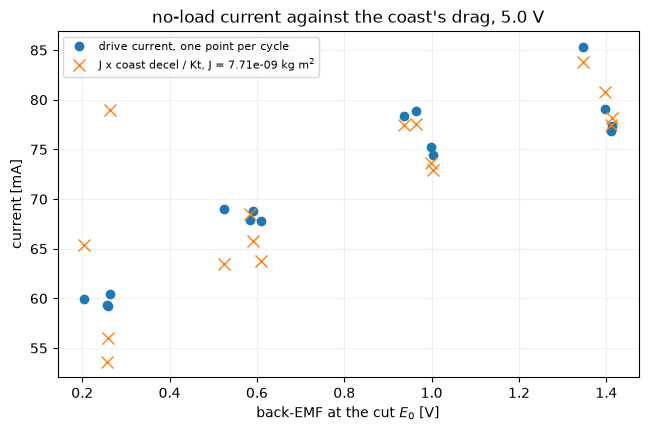

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
t = SPIN[SPIN.turn]
ax.plot(t.E0_lin, t.i_counts / CPA * 1e3, "o", label="drive current, one point per cycle")
# the coast's own deceleration at the same EMF, as a current through one J
ax.plot(t.E0_lin, J.mean() * t.dec_E0 / KE ** 2 * 1e3, "x", ms=8, label=f"J x coast decel / Kt, J = {J.mean():.2e} kg m$^2$")
ax.set_xlabel("back-EMF at the cut $E_0$ [V]")
ax.set_ylabel("current [mA]")
ax.set_title("no-load current against the coast's drag, 5.0 V")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** The drive current per turning cycle against its EMF at the cut, and,
for the same cycles, the coast's deceleration at that EMF expressed as a current through the one
$J$. Where the crosses sit on the dots, the coast's drag accounts for the drive current.

## 4. The back-EMF constant

Two routes, both counting the ripple for speed.

- **Coast, same window.** The mean terminal EMF over a whole number of ripple cycles, 1 to 11 ms
  into the coast, over the speed counted in the same samples. The current is zero, the voltage and
  the speed come from one channel and one window, and integer cycles make the mean exact.
- **Spin.** $E_0$ extrapolated to the duty-0 tick over the spin's own counted speed. This assumes
  the speed does not jump at the cut.

,n,Ke V s/rad,sd %,se %,"per rung, mV s/rad"
estimator,,,,,
"coast same-window: mean E / counted speed, 1-11 ms",12,0.001172,1.264600,0.365058,"{20: 1.1841, 30: 1.1663, 40: 1.1665}"
spin: E extrapolated to the duty-0 tick / spin speed,16,0.001150,5.435479,1.358870,"{12: 1.069, 20: 1.1722, 30: 1.1805, 40: 1.1792}"


paired spin / coast - 1: +0.45% (sd 2.13%, se 0.61%, n 12)
12% coasts counted: [0.0, 0.0, 0.0, 0.0] ripple cycles in 1-11 ms (Ke_coast needs a count)
Ke = 1.1723e-03 V s/rad = 7.366 mV per rev/s = 1.2276 mV per ripple Hz; median 1.1713e-03 (the Kt below)
registry ke_ripple_measured 1.295 [1.284, 1.306] mV per ripple Hz (nb09 sec 3, settled windows of the 15-50% grid rungs, 2S session, back-EMF against counted ripple frequency, R pinned): this coast reads -5.2%


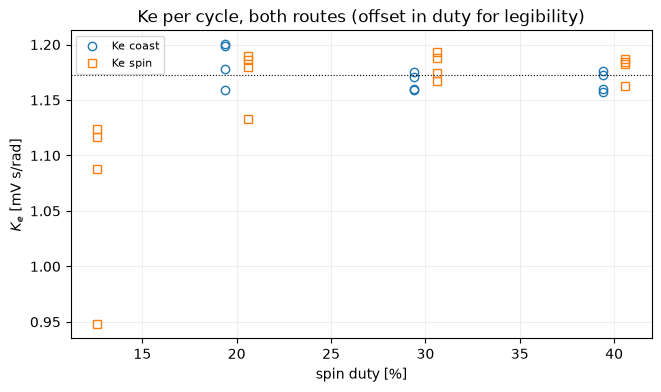

In [10]:
rows = []
for col, what in (("Ke_coast", "coast same-window: mean E / counted speed, 1-11 ms"),
                  ("Ke_spin", "spin: E extrapolated to the duty-0 tick / spin speed")):
    x = SPIN[col].dropna()
    rows.append({"estimator": what, "n": len(x), "Ke V s/rad": x.mean(), "sd %": x.std() / x.mean() * 100,
                 "se %": x.std() / np.sqrt(len(x)) / x.mean() * 100,
                 "per rung, mV s/rad": {int(k): round(float(v) * 1e3, 4) for k, v in SPIN.groupby("duty")[col].mean().dropna().items()}})
KETAB = pd.DataFrame(rows).set_index("estimator")
display(KETAB)
pair = SPIN.dropna(subset=["Ke_spin", "Ke_coast"])
dr = pair.Ke_spin / pair.Ke_coast - 1
KE_MEAN = SPIN.Ke_coast.mean()
print(f"paired spin / coast - 1: {dr.mean() * 100:+.2f}% (sd {dr.std() * 100:.2f}%, se {dr.std() / np.sqrt(len(dr)) * 100:.2f}%, n {len(dr)})")
print("12% coasts counted:", SPIN[SPIN.duty == 12].coast_ncyc.tolist(), "ripple cycles in 1-11 ms (Ke_coast needs a count)")
print(f"Ke = {KE_MEAN:.4e} V s/rad = {KE_MEAN * 2 * np.pi * 1e3:.3f} mV per rev/s = {KE_MEAN * 2 * np.pi / EV_PER_REV * 1e3:.4f} mV per ripple Hz; "
      f"median {KE:.4e} (the Kt below)")
reg = servo.measured["ke_ripple_measured"]
print(f"registry ke_ripple_measured {reg.value} [{reg.lo}, {reg.hi}] {reg.unit} ({reg.source}): this coast reads "
      f"{(KE_MEAN * 2 * np.pi / EV_PER_REV * 1e3 / reg.value - 1) * 100:+.1f}%")
fig, ax = plt.subplots(figsize=(7.5, 4))
for col, m in (("Ke_coast", "o"), ("Ke_spin", "s")):
    ax.plot(SPIN.duty + (0.6 if col == "Ke_spin" else -0.6), SPIN[col] * 1e3, m, mfc="none", label=col.replace("_", " "))
ax.axhline(KE_MEAN * 1e3, color="k", lw=0.8, ls=":")
ax.set_xlabel("spin duty [%]")
ax.set_ylabel("$K_e$ [mV s/rad]")
ax.set_title("Ke per cycle, both routes (offset in duty for legibility)")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** Each route's mean, its spread and standard error, and the per-rung
means, then the paired difference, the 12% counts, the constant in the other units, and the
registry. The plot is every cycle's $K_e$ by both routes.

- **$K_e$ = 1.1723e-3 V s/rad from the coast, se 0.37%, n 12.** Flat across 20, 30 and 40%. It is
  7.366 mV per motor rev/s, or 1.2276 mV per ripple Hz.
- **The spin route agrees.** Paired cycle by cycle it reads +0.45% +/- 0.61%. Its spread is wider,
  and the 12% rung reads 9% low by itself, where the coast has no count to check it against. The
  coast route is the one to use: no current, the same samples, whole cycles.
- **The registry disagrees by 5.2%.** Notebook 09's in-servo value, 1.295 mV per ripple Hz, came from
  board D with the gearbox on and $R$ pinned in a drive fit. This is a bare motor on rev 2A through
  an open-circuit route. Section 10 lists it. Nothing here separates the board, the route and the
  gearbox.

## 5. Inductance

**The ramp route, withdrawn.** The firmware ramps the duty from 6% to the spin duty at 128 q15 per
tick, with the rotor still locked at the ramp's start. The idea was to fit the current's response to
the recorded ramp with one RL pole (resistance and inductance in series),

$$i_k = a i_{k-1} + (1 - a) \frac{D_{k-1} V_{on}}{R}, \qquad a = e^{-T/\tau}, \qquad L = R \tau$$

with $R$ pinned to the same cycle's stalled V/I, so the time constant $\tau$ is the only free
parameter. Current is settle-gained, multiplied by the firmware's shunt settle-gain table for each
tick's window width (`oscnb.minduty`). The fit runs over N ticks after the first ramp tick, twice:
with the duty read back at tick k taking effect from tick k+1 (the `rlstep` alignment) and with one
tick more delay. The table sets this run beside the analysis note's run of the same code on the same
data.

In [11]:
TAB = minduty.settle_gain()                                      # the board file's shunt settle-gain table, as main ships it
out = []
for k in SPIN[SPIN.duty >= 8].index:
    r = CY.loc[k]
    seg = ss.segments(ss.frame(DS, k), r.steps)
    st, sp = seg["stall"], seg["spin"]
    x = pd.concat([st.iloc[-60:], sp.iloc[:200]], ignore_index=True)   # the end of the 6% hold and the ramp
    q = (x.duty_q15 * r.dir).to_numpy(float)
    gain = np.array([minduty.settle_gain_at(hh, TAB) for hh in minduty.drive_ticks(q)])
    i = (x.current_raw - x.current_trough).to_numpy(float) * gain / CPA
    D = q / Q15
    von = ((sp.vmotor_a - sp.vmotor_b) * r.dir).iloc[-2000:].mean() * VPC
    i6, D6 = i[:55].mean(), D[:55].mean()
    R = D6 * von / i6                                                # pinned: the same cycle's stalled V/I
    k0 = int(np.flatnonzero(np.diff(D) > 0)[0]) + 1                  # first sample reporting the new duty
    for extra in (0, 1):
        for N in (6, 8, 10, 14, 20, 30):
            idx = np.arange(k0 - 5, k0 + N)
            def sim(p):
                a = np.exp(-T_PWM / p[0])
                y = np.empty(len(idx))
                y[0] = i6
                for j in range(1, len(idx)):
                    y[j] = a * y[j - 1] + (1 - a) * D[idx[j] - 1 - extra] * von / R
                return y - i[idx]
            f = least_squares(sim, [150e-6], bounds=([10e-6], [2e-3]))
            out.append(dict(cycle=k, duty=r.duty, extra=extra, N=N, tau_us=f.x[0] * 1e6, R_pin=R, L_mH=R * f.x[0] * 1e3))
RAMP = pd.DataFrame(out)
NOTE = pd.read_csv(DS.path / "ref/ramp-fits-analysis-note.csv")      # the analysis note's run of the same fit
cmp_ = RAMP.merge(NOTE, on=["cycle", "extra", "N"], suffixes=("", "_note"))
tab = cmp_.groupby(["extra", "N"]).agg(n=("tau_us", "size"), tau_us=("tau_us", "median"), tau_note=("tau_us_note", "median"),
                                       L_mH=("L_mH", "median"), L_note=("L_mH_note", "median"))
tab["tau ratio"] = tab.tau_us / tab.tau_note
display(tab.round(3))
rp = cmp_.R_pin / cmp_.R_pin_note
print(f"R_pin median {RAMP.R_pin.median():.3f} ohm here, {NOTE.R_pin.median():.3f} in the note's run; ratio here / note "
      f"{rp.median():.5f} (spread {rp.min():.5f}..{rp.max():.5f}) on every fit")
print(f"settle gain at the stalled 6% window ({minduty.drive_ticks(np.array([0.06 * Q15]))[0]} ticks) in the table main ships: "
      f"{minduty.settle_gain_at(minduty.drive_ticks(np.array([0.06 * Q15]))[0], TAB):.5f}")
e8 = RAMP[(RAMP.duty == 8) & (RAMP.extra == 0)].groupby("N").tau_us.median()
e8n = NOTE[(NOTE.duty == 8) & (NOTE.extra == 0)].groupby("N").tau_us.median()
print(f"the 8% cycles (never turn): tau {e8.loc[6]:.0f} -> {e8.loc[30]:.0f} us from N 6 to 30 here, "
      f"{e8n.loc[6]:.0f} -> {e8n.loc[30]:.0f} in the note's run")

n   tau_us  tau_note   L_mH  L_note  tau ratio
extra N                                                  
0     6   19  271.697   253.779  1.166   1.095      1.071
      8   19  293.557   276.910  1.210   1.150      1.060
      10  19  297.003   282.713  1.259   1.189      1.051
      14  19  308.651   296.540  1.264   1.221      1.041
      20  19  344.788   333.360  1.396   1.355      1.034
      30  19  460.505   447.296  1.929   1.885      1.030
1     6   19  151.878   140.343  0.640   0.594      1.082
      8   19  191.577   178.694  0.797   0.748      1.072
      10  19  203.991   192.919  0.875   0.832      1.057
      14  19  229.575   219.243  0.939   0.903      1.047
      20  19  277.023   266.576  1.123   1.087      1.039
      30  19  391.679   379.346  1.643   1.600      1.033

R_pin median 4.193 ohm here, 4.216 in the note's run; ratio here / note 0.99444 (spread 0.99444..0.99444) on every fit
settle gain at the stalled 6% window (72 ticks) in the table main ships: 1.02670
the 8% cycles (never turn): tau 256 -> 608 us from N 6 to 30 here, 239 -> 548 in the note's run


**What you are looking at.** Per alignment and fit length, the cycles, the median $\tau$ and $L$
here and in the note's run, and their ratio. Under it the pinned R both ways, the settle gain at the
stalled window, and the 8% cycles' growth.

- **There is no flat band.** $\tau$ grows from 272 to 461 us as the window goes from 6 to 30 ticks,
  and one tick of alignment moves it by 70 to 120 us. An RL pole fitted to its own response would
  give one $\tau$ at every length.
- **It is not the rotor's EMF entering the window.** The 8% cycles never turn, and their $\tau$ grows
  the same way, 256 to 608 us. The window holds a slow component that is not the inductance.
- **This run and the note's disagree, and the cause is not known.** This run's $\tau$ reads 3 to 8%
  higher, and its pinned R reads exactly 0.99444 of the note's on every fit. A constant ratio on
  every fit points at one scale on the stalled 6% current, and the settle-gain table that scales it
  comes from the firmware's board file, which changed on main between the note's run and this one.
  That is the candidate, and nothing here confirms it. It changes no conclusion, because the route is
  withdrawn either way.

In [12]:
rows = []
for k in SPIN[SPIN.duty == 8].index:
    r = CY.loc[k]
    seg = ss.segments(ss.frame(DS, k), r.steps)
    x = pd.concat([seg["stall"].iloc[-100:], seg["spin"]], ignore_index=True)
    q = (x.duty_q15 * r.dir).to_numpy(float)
    gg = np.array([minduty.settle_gain_at(hh, TAB) for hh in minduty.drive_ticks(q)])
    i = (x.current_raw - x.current_trough).to_numpy(float) * gg
    k0 = int(np.flatnonzero(np.diff(q) > 0)[0]) + 1
    i6, i8 = i[:95].mean(), i[-2000:].mean()
    for t_ms in (0.25, 0.5, 1, 2, 5, 10, 25, 50, 100, 200):
        kk = k0 + int(t_ms * 20)
        rows.append(dict(cycle=k, t_ms=t_ms, missing_pct=100 * (i8 - i[kk - 2:kk + 3].mean()) / (i8 - i6),
                         DI_ratio=((q[-2000:].mean() / Q15) / i8) / ((q[:95].mean() / Q15) / i6)))
TAIL = pd.DataFrame(rows)
display(TAIL.pivot_table(index="t_ms", columns="cycle", values="missing_pct").round(1))
DI = TAIL.groupby("cycle").DI_ratio.first()
print("D/I at 8% over D/I at 6%, same hold:", {int(k): round(float(v), 4) for k, v in DI.items()})
print("one RL pole leaves of a step at 1.5 ms: " + ", ".join(f"tau {tu} us {np.exp(-1500 / tu) * 100:.2f}%" for tu in (150, 300)))

cycle,10,11,21
t_ms,,,
0.25,53.3,41.1,50.3
0.50,13.0,4.1,18.2
1.00,4.8,-10.5,6.6
2.00,9.4,27.1,12.9
5.00,9.4,38.1,5.5
10.00,10.6,27.1,2.4
25.00,-1.1,7.7,3.4
50.00,8.3,12.6,-1.8
100.00,0.1,5.3,0.3


D/I at 8% over D/I at 6%, same hold: {10: 1.0713, 11: 1.085, 21: 1.0602}
one RL pole leaves of a step at 1.5 ms: tau 150 us 0.00%, tau 300 us 0.67%


**What you are looking at.** For the three 8% cycles, the share of the 6% to 8% current step still
missing at each time after the ramp's first tick, and the D/I ratio at 8% over 6% inside one hold.

A single RL pole of 150 to 300 us would leave under 1% of the step by 1.5 ms. Here cycles 10 and 21
still miss 2 to 13% from 2 to 10 ms, and cycle 11 misses 27 to 38%, then all three settle by 100 to
200 ms. That slow part is what the long fits fold into $\tau$. The candidates are eddy currents in
the rotor iron and a contact settling under the new current. A locked-rotor burst held 0.5 to 5 ms
would show the slow part directly, and it would show whether it scales with the step (eddy) or
depends on the seat (contact).

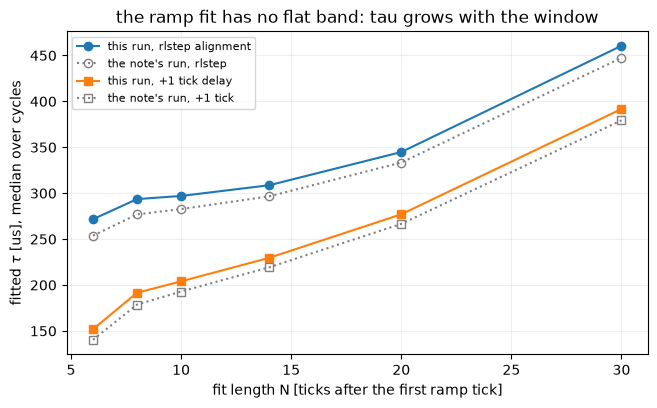

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for extra, m in ((0, "o"), (1, "s")):
    t = tab.xs(extra, level="extra")
    ax.plot(t.index, t.tau_us, m + "-", label=f"this run, {'rlstep alignment' if extra == 0 else '+1 tick delay'}")
    ax.plot(t.index, t.tau_note, m + ":", mfc="none", color="grey", label=f"the note's run, {'rlstep' if extra == 0 else '+1 tick'}")
ax.set_xlabel("fit length N [ticks after the first ramp tick]")
ax.set_ylabel(r"fitted $\tau$ [us], median over cycles")
ax.set_title("the ramp fit has no flat band: tau grows with the window")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** The median fitted $\tau$ against the fit length, both alignments, solid
for this run and dotted for the note's. Neither curve has a plateau to read an inductance from.

In [14]:
rep = (DS.path / "e8/capture-1/report.log").read_text()
w = heating.WAVE.search(rep)
env = re.search(r"envelope\s+tau ([\d.]+) us", rep)
short = re.search(r"ON window ([\d.]+) us short of commanded", rep)
verdict = heating.VERDICT.search(rep)[1]
E8 = dict(R=float(w[1]), R_sd=float(w[2]), L_mH=float(w[3]), kept=int(w[5]), tau_env_us=float(env[1]), on_short_us=float(short[1]))
print(f"E8 burst at 20%, {E8['kept']} captures: waveform R {E8['R']} +/- {E8['R_sd']} ohm, L {E8['L_mH']} mH; "
      f"envelope tau {E8['tau_env_us']} us; verdict {verdict}")
print(f"the in-servo identification's L for the same motor: {L_IN_SERVO * 1e3:.3f} mH; with the E8 L instead, the ON slopes of "
      f"section 3 scale by {L_IN_SERVO * 1e3 / E8['L_mH']:.2f} and the offsets of section 6 by {E8['L_mH'] / (L_IN_SERVO * 1e3):.2f}")

E8 burst at 20%, 2 captures: waveform R 4.574 +/- 0.171 ohm, L 0.843 mH; envelope tau 129.0 us; verdict declined
the in-servo identification's L for the same motor: 0.757 mH; with the E8 L instead, the ON slopes of section 3 scale by 0.90 and the offsets of section 6 by 1.11


**The E8 burst.** The one `osc ident burst --static-load` run on the bare motor, at 20% from rest
in both directions, fits the waveform with $L$ = 0.843 mH and $R$ = 4.574 +/- 0.171 ohm, with an
envelope time constant of 129 us. It declined itself: two captures cannot pass the
capture-agreement or split-halves gates. The in-servo identification of the same motor fit 0.757
mH on 16 captures. Two declined captures are not a measurement. What this dataset says about $L$ is
that a burst route gives 0.76 to 0.84 mH where the ramp gives anything from 0.6 to 1.9.

## 6. Resistance in rotation

The model-free route needs no $K_e$. At steady spin the drive voltage less the back-EMF is the
resistive drop, and the coast's $E_0$ is the back-EMF at the cut,

$$R_{rot} = \frac{D V_{on} - E_0}{I}$$

Then the excess voltage over the rest floor, $dV = D V_{on} - E_0 - R_{p10} I$, is fitted against
speed ($E_0$) to see what it scales with.

,n,R_rot,sd,I_mA,E0,se
duty,,,,,,
12,4,5.316,0.462,59.746,0.246,0.231
20,4,5.262,0.486,68.376,0.577,0.243
30,4,5.563,0.261,76.753,0.975,0.130
40,4,5.974,0.071,79.653,1.392,0.036


all turning: R_rot 5.529 +/- 0.109 ohm (n 16); over the char rest p10 4.649: +0.88 ohm = 8.1 se
excess voltage dV = D V_on - E0 - 4.65 I = 0.0194 (se 0.0136) V + 0.0565 (se 0.0150) x E0
12% -> 40%: current x1.33, dV x2.65; 40% dV over a current-scaled 12% dV: 2.7 sigma by both rungs' se, 9.7 by the 40% rung's alone
sample offset a ripple-phase term would need, us: {12: 1.55, 20: 1.8, 30: 3.43, 40: 5.92}
the E8 report's ON-window shortfall 0.54 us at this rail: 0.049 V of drive, against the intercept 0.019 V


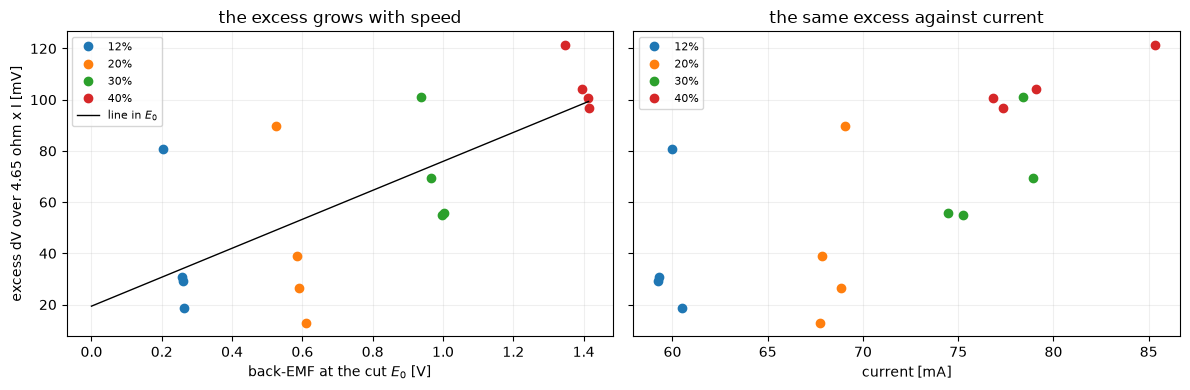

In [15]:
SPIN["R_rot"] = (SPIN.V_drive - SPIN.E0_lin) / SPIN.i_A          # model-free: (D V_on - E0) / I
t = SPIN[SPIN.turn]
gr = t.groupby("duty").agg(n=("R_rot", "size"), R_rot=("R_rot", "mean"), sd=("R_rot", "std"), I_mA=("i_A", lambda x: 1e3 * x.mean()),
                           E0=("E0_lin", "mean"))
gr["se"] = gr.sd / np.sqrt(gr.n)
display(gr.round(3))
RR = dict(mean=t.R_rot.mean(), se=t.R_rot.std() / np.sqrt(len(t)), n=len(t))
print(f"all turning: R_rot {RR['mean']:.3f} +/- {RR['se']:.3f} ohm (n {RR['n']}); over the char rest p10 {p10:.3f}: "
      f"{RR['mean'] - p10:+.2f} ohm = {(RR['mean'] - p10) / RR['se']:.1f} se")
R_REST = round(p10, 2)                                              # the p10 as the note quotes it
t = t.assign(dV=t.V_drive - t.E0_lin - R_REST * t.i_A)
A = np.vstack([np.ones(len(t)), t.E0_lin]).T
coef, *_ = np.linalg.lstsq(A, t.dV, rcond=None)
res = t.dV - A @ coef
cov = res.var(ddof=2) * np.linalg.inv(A.T @ A)
print(f"excess voltage dV = D V_on - E0 - {R_REST} I = {coef[0]:.4f} (se {np.sqrt(cov[0, 0]):.4f}) V "
      f"+ {coef[1]:.4f} (se {np.sqrt(cov[1, 1]):.4f}) x E0")
dv = t.groupby("duty").agg(dV=("dV", "mean"), sd=("dV", "std"), n=("dV", "size"), I=("i_A", "mean"))
dv["se"] = dv.sd / np.sqrt(dv.n)
lo, hi = dv.loc[12], dv.loc[40]
pred = lo.dV * hi.I / lo.I                                          # a contact term scales with current
Z_BOTH = (hi.dV - pred) / np.hypot(hi.se, lo.se * hi.I / lo.I)
Z_40 = (hi.dV - pred) / hi.se
print(f"12% -> 40%: current x{hi.I / lo.I:.2f}, dV x{hi.dV / lo.dV:.2f}; 40% dV over a current-scaled 12% dV: "
      f"{Z_BOTH:.1f} sigma by both rungs' se, {Z_40:.1f} by the 40% rung's alone")
OFFS = {d: dv.loc[d, "dV"] / R_REST * 1e3 / L_bound[d] for d in dv.index}   # mA of excess over mA per us
print("sample offset a ripple-phase term would need, us:", {int(k): round(float(v), 2) for k, v in OFFS.items()})
ONL = E8["on_short_us"] * 1e-6 / T_PWM * SPIN.Von.mean()
print(f"the E8 report's ON-window shortfall {E8['on_short_us']} us at this rail: {ONL:.3f} V of drive, against the intercept {coef[0]:.3f} V")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for duty, gg in t.groupby("duty"):
    a1.plot(gg.E0_lin, gg.dV * 1e3, "o", label=f"{duty}%")
    a2.plot(gg.i_A * 1e3, gg.dV * 1e3, "o", label=f"{duty}%")
e = np.linspace(0, t.E0_lin.max(), 20)
a1.plot(e, (coef[0] + coef[1] * e) * 1e3, "k-", lw=1, label="line in $E_0$")
a1.set_xlabel("back-EMF at the cut $E_0$ [V]")
a2.set_xlabel("current [mA]")
a1.set_ylabel(f"excess dV over {R_REST} ohm x I [mV]")
a1.set_title("the excess grows with speed")
a2.set_title("the same excess against current")
for a in (a1, a2):
    a.grid(alpha=0.2)
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at.** Per rung, $R_{rot}$ with its spread and se, the current and the EMF.
Under it the pooled value against the rest floor, the excess voltage's line in $E_0$, the two
single-cause tests and the ON-window term. The plot is the excess against speed and against current.

- **The motor turning shows 5.53 +/- 0.11 ohm, 0.88 over the rest floor, 8.1 se.** The rungs read
  5.32, 5.26, 5.56 and 5.97 from 12 to 40%, rising from 30%. The 40% rung is the tightest, se 0.04.
- **The excess grows with speed.** $dV$ = 0.019 +/- 0.014 V plus 0.057 +/- 0.015 times $E_0$. The
  intercept is not distinguishable from zero.
- **A contact term alone does not fit.** A resistance in series scales its drop with current. From
  12 to 40% the current rises 1.33 times and the excess 2.65 times. Against a current-scaled 12%
  excess the 40% rung sits 2.7 sigma high using both rungs' se, or 9.7 using the 40% rung's alone.
  The 12% rung's larger se is why the two readings differ.
- **A sampling-phase term alone does not fit either.** For the current sample to read the excess as
  a constant offset into the ON ramp, the offset would have to grow from 1.55 us at 12% to 5.92 us
  at 40%. A timing offset does not grow with duty.
- **The ON-window shortfall is at most the intercept.** The E8 report puts the ON window 0.54 us
  short of commanded, 0.049 V of drive at this rail, against an intercept of 0.019 +/- 0.014 V. It
  cannot be the slope.

What is left standing is a term proportional to speed. A commutation voltage, the brush arcing or
the coil's L di/dt at each segment change, scales with how often segments change, which is speed.
A speed-dependent brush drop would too. They separate with two loads at one speed: the same speed
at two currents, by a brake on the shaft, splits a speed term from a current term.

## 7. Breakaway

The ladder runs on a 3.76 V rail, each rung 2 s of OpenLoop duty polled at 25 ms, from 1% to 40%,
with no move between rungs, so a locked rung sits on whatever seat the last one left. A rung is
locked if its current's sd is at most 4.5 counts and its V/I sits above 3.5 ohm, the quiet signature
of a stalled rotor. Torque is $K_t I$ with $K_t = K_e$, the coast route's median. Aaron watched the
ladder: no motion from 1 to 13%, first motion at 14%.

,duty_pct,rail_V,V,I_mA,i_sd_counts,state,V_over_I,T_mNm
file,,,,,,,,
d1pct-4v.csv,1.001,3.758,0.038,0.791,1.317,locked,47.571,0.001
ladder-4v-5.csv,4.999,3.752,0.188,43.502,1.277,locked,4.312,0.051
ladder-4v-10.csv,10.001,3.742,0.374,76.082,1.864,locked,4.918,0.089
manual-4v-5.csv,13.999,3.742,0.524,52.066,8.174,turning,10.061,0.061
ladder-4v-15.csv,15.000,3.721,0.558,122.006,1.545,locked,4.575,0.143
ladder-4v-20.csv,19.999,3.725,0.745,62.204,8.384,turning,11.974,0.073
ladder-4v-25.csv,25.001,3.716,0.929,63.987,11.238,turning,14.518,0.075
ladder-4v-30.csv,30.000,3.714,1.114,66.658,12.934,turning,16.716,0.078
ladder-4v-35.csv,34.999,3.713,1.299,68.018,15.325,turning,19.104,0.080


Kt = Ke = 1.1713e-03 N m/A; highest locked rung 15% at 122 mA = 0.143 mN m = 1.46 g cm; lowest turning rung 14% at 0.524 V; running torque 0.061..0.082 mN m; held over running 1.7..2.3
5.0 V char: 8% held at 78.5..83.6 mA (n 3, none turned), 12% turned in 4 of 4; drive voltage D x V_on: 8% 0.374 V, 12% 0.564 V


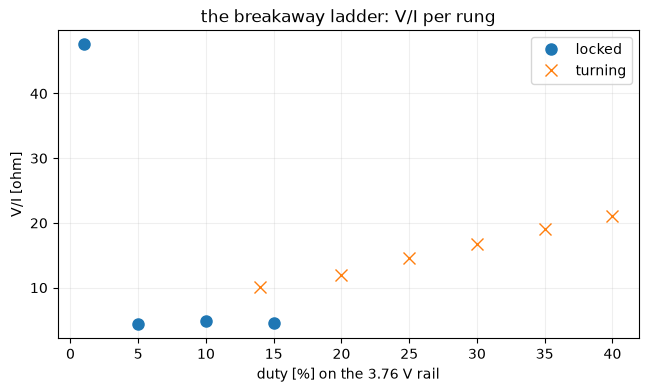

In [16]:
rows = []
for f in sorted((DS.path / "breakaway").glob("*.csv")):
    d = pd.read_csv(f)
    on = d[(d.leg == "on") & (d.duty_applied_q15 > 0)]
    if not len(on):
        continue
    i = on.current - on.current_trough
    D = on.duty_applied_q15.mean() / Q15
    rail = board.vsys_v(on.vbus_raw.mean())
    I = i.mean() / CPA
    # a locked rotor is quiet: current sd at most 4.5 counts and V/I near the winding
    state = "locked" if i.std() <= 4.5 and D * rail / I > 3.5 else "turning"
    rows.append(dict(file=f.name, t0=d.t_unix.min(), duty_pct=100 * D, rail_V=rail, V=D * rail, I_mA=1e3 * I, i_sd_counts=i.std(),
                     state=state, V_over_I=D * rail / I, T_mNm=1e3 * KE * I))
BRK = pd.DataFrame(rows).sort_values("duty_pct").set_index("file")
display(BRK.drop(columns="t0").round(3))
lk, tn = BRK[BRK.state == "locked"], BRK[BRK.state == "turning"]
print(f"Kt = Ke = {KE:.4e} N m/A; highest locked rung {lk.duty_pct.max():.0f}% at {lk.I_mA.max():.0f} mA = {lk.T_mNm.max():.3f} mN m "
      f"= {lk.T_mNm.max() * 10.197:.2f} g cm; lowest turning rung {tn.duty_pct.min():.0f}% at {tn.loc[tn.duty_pct.idxmin(), 'V']:.3f} V; "
      f"running torque {tn.T_mNm.min():.3f}..{tn.T_mNm.max():.3f} mN m; held over running "
      f"{lk.T_mNm.max() / tn.T_mNm.max():.1f}..{lk.T_mNm.max() / tn.T_mNm.min():.1f}")
h8 = SPIN[SPIN.duty == 8].i_counts / CPA * 1e3
print(f"5.0 V char: 8% held at {h8.min():.1f}..{h8.max():.1f} mA (n {len(h8)}, none turned), 12% turned in {int(SPIN[SPIN.duty == 12].turn.sum())} of "
      f"{int((SPIN.duty == 12).sum())}; drive voltage D x V_on: "
      + ", ".join(f"{d}% {(SPIN[SPIN.duty == d].D * SPIN[SPIN.duty == d].Von).mean():.3f} V" for d in (8, 12)))
fig, ax = plt.subplots(figsize=(7.5, 4))
for st_, m in (("locked", "o"), ("turning", "x")):
    b = BRK[BRK.state == st_]
    ax.plot(b.duty_pct, b.V / (b.I_mA / 1e3), m, ms=8, label=st_)
ax.set_xlabel("duty [%] on the 3.76 V rail")
ax.set_ylabel("V/I [ohm]")
ax.set_title("the breakaway ladder: V/I per rung")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

**What you are looking at.** Every rung in duty order, its rail, drive voltage, current, the
current's sd in counts, the locked or turning call and the torque $K_t I$. Under it the summary and
the 5.0 V char cycles' locked and turning rungs. The plot is V/I per rung.

- **The motor breaks away near half a volt.** It turned at 14% on one seat, 0.524 V (the manual run
  named manual-4v-5, which ran at 14%), and held at 15% on another, 0.558 V. At 5.0 V the char's 8%
  rung (0.374 V) held in all three cycles and 12% (0.564 V) turned in all four.
- **The largest torque a seat held is 0.143 mN m.** The 15% rung drew 122 mA locked, 1.46 g cm. That
  is a lower bound on that seat's breakaway torque, not the breakaway torque itself.
- **Turning takes 0.061 to 0.082 mN m.** That is the current of the turning rungs through $K_t$,
  rising with duty, the same speed-dependent drag as section 3. Held over running torque is 1.7 to 2.3
  on the seat that held 15%.
- **Locked V/I is not a resistance here.** It reads 4.32, 4.92 and 4.57 ohm at 5, 10 and 15% on the
  3.76 V rail, scattered across the meter's whole range, and it carries the window-length effects
  of the next section.

## 8. The two-current stall slope

The two-duty test holds the rotor at a seat and pulses 6% then 8%, five pairs, 300 ms each, then a
12% spin moves it to a new seat. The idea: a slope between two currents at one seat cancels any
constant offset, a fixed ON-window shortfall or a sample offset, that a single-point V/I keeps.
`th drive` polled at 20 ms, so nothing here says whether a stalled pulse moved the rotor, and every
pulse's motion is unknown. The quiet set keeps pulses with a current sd at most 4.5 counts, a
secondary gate that was not pre-registered. Currents are recomputed through the board's counts per
amp.

In [17]:
p = pd.read_csv(DS.path / "two-current/pulses.csv")
p = p[p.tag.str.contains("d6|d8")].copy()
p["seat"] = p.tag.str[1:3].astype(int)
p["d"] = p.tag.str[-1].astype(int)
p["I"] = p.i_counts / CPA                                  # the board's counts per amp, not the runner's 1118
p["quiet"] = p.i_sd <= 4.5
rows = []
for s, gg in p.groupby("seat"):
    for label, x in (("all", gg), ("quiet pulses only", gg[gg.quiet])):
        a, b8 = x[x.d == 6], x[x.d == 8]
        rows.append(dict(seat=s, set=label, n6=len(a), n8=len(b8), R_point6=a.v_on.mean() / a.I.mean(),
                         R_point8=b8.v_on.mean() / b8.I.mean(),
                         R_slope=(b8.v_on.mean() - a.v_on.mean()) / (b8.I.mean() - a.I.mean())))
TWO = pd.DataFrame(rows).set_index(["seat", "set"])
mt, mv = ml.read(DS.path / "two-current/dmm.csv")
TWO["meter rest"] = np.nan
seats = pd.read_csv(DS.path / "two-current/seats.csv").set_index("seat")
for s in seats.index:
    TWO.loc[(s, "all"), "meter rest"] = seats.loc[s, "rest_R"]
display(TWO.round(3))
print(f"ON time at 6% and 8% of the {T_PWM * 1e6:.0f} us period: {0.06 * T_PWM * 1e6:.1f} and {0.08 * T_PWM * 1e6:.1f} us")

n6  n8  R_point6  R_point8  R_slope  meter rest
seat set                                                               
1    all                 5   5     4.158     4.703    7.761        4.77
     quiet pulses only   5   4     4.158     4.339    4.993         NaN
2    all                 5   5     4.084     4.246    4.825        4.84
     quiet pulses only   5   5     4.084     4.246    4.825         NaN
3    all                 5   5     4.097     4.428    5.850        4.79
     quiet pulses only   5   5     4.097     4.428    5.850         NaN

ON time at 6% and 8% of the 50 us period: 3.0 and 4.0 us


**What you are looking at.** Per seat and set, the pulse counts, the single-point V/I at 6% and at
8%, the slope between them, and the meter's rest reading before the seat.

**This is not a verdict.** Seat 2 is quiet throughout and its slope, 4.83 ohm, sits on its meter
reading, 4.84. Seat 1's slope swings from 7.76 to 4.99 when one noisy 8% pulse leaves, and seat 3's
5.85 is quiet by the gate. The single points read 4.08 to 4.16 at 6% and 4.25 to 4.70 at 8%, all
under the meter. At 20 kHz the 6% and 8% windows are 3.0 and 4.0 us of ON in a 50 us period, so
window-length effects (the settle of the shunt amplifier, a turn-on transient) differ between the
two duties. That breaks the slope's cancellation. The char data agrees in kind: inside one hold,
D/I rises 6.0 to 8.5% from 6% to 8% (section 5), the opposite of what an ON-window shortfall would
do. Window-length effects dominate both routes at these duties.

## 9. Part 2b, described

Part 2b ran after J4 was re-seated: 27 more cycles at 5.0 V, then 50 at 7.4 V. The 7.4 V block has
no stalled pre-pulse, so it has no same-cycle R to pin, and the per-cycle estimators of sections 3
to 6 are not available there. None of them are applied here. This section only describes the spin
current over the last 100 ms (the same window as section 3), the applied duty, and the coast's EMF
1 to 2 ms in. The 5% rungs have no coast segment by design.

n      mA  mA_sd  applied  applied_min  E_coast
rail duty                                                 
5.0  5     7  58.960  1.859    4.999        4.999      NaN
     8     4  81.415  1.994    7.999        7.999   -0.021
     12    4  61.106  3.571   12.000       12.000    0.261
     20    3  70.543  1.801   19.999       19.999    0.565
     30    4  77.215  2.802   30.000       30.000    0.993
     40    4  82.087  4.772   39.998       39.998    1.378
7.4  5     8  92.061  6.801    4.999        4.999      NaN
     8     8  67.360  2.251    7.999        7.999    0.272
     12    9  74.059  1.834   12.000       11.853    0.529
     20    8  85.377  1.735   19.999       19.999    0.991
     30    9  92.868  4.737   29.333       10.639    1.592
     40    7  99.184  3.251   33.375        5.780    1.752

part 2b over part 1 at 5.0 V, mA per rung: 5% +0.6, 8% +0.8, 12% +1.4, 20% +2.2, 30% +0.5, 40% +2.4
7.4 V set reads 7.14 V: 5% is 0.357 V, 8% is 0.571 V of drive; the 280-count limit is 253 mA
cycles whose applied duty fell more than 1 point under the command after the first 50 ms:


,rail,duty,dir,mA,applied_last,applied_min,E_coast_1_2ms
cycle,,,,,,,
92,7.4,30,-1,90.62,29.83,25.75,1.70
93,7.4,30,1,102.89,24.17,10.64,1.28
98,7.4,40,-1,103.71,27.86,11.79,1.51
99,7.4,40,1,102.20,5.78,5.78,-0.01


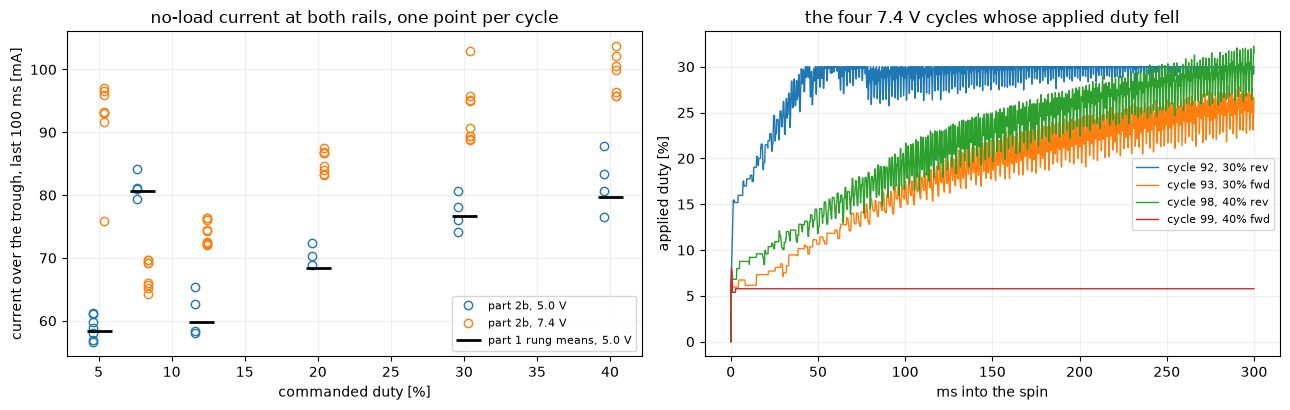

In [18]:
rows = []
for k in CY[(CY.part == "2b") & CY.captured].index:
    r = CY.loc[k]
    seg = ss.segments(ss.frame(DS, k), r.steps)
    sp, co = seg["spin"], seg["coast"]
    w = sp.iloc[-2000:]                                            # the spin's last 100 ms, as in section 3
    duty_app = (sp.duty_q15 * r.dir / Q15 * 100).to_numpy()
    E = np.nan
    if len(co):
        z = np.flatnonzero(co.duty_q15.to_numpy() == 0)
        if len(z):
            E = (((co.vmotor_a - co.vmotor_b) * r.dir).to_numpy(float)[z[0]:] * VPC)[20:40].mean()   # 1-2 ms into the coast
    rows.append(dict(cycle=k, rail=r.rail, duty=r.duty, dir=r.dir, mA=(w.current_raw - w.current_trough).mean() / CPA * 1e3,
                     applied_last=duty_app[-2000:].mean(), applied_min=duty_app[1000:].min(), E_coast_1_2ms=E))
B2 = pd.DataFrame(rows).set_index("cycle")
s2 = B2.groupby(["rail", "duty"]).agg(n=("mA", "size"), mA=("mA", "mean"), mA_sd=("mA", "std"), applied=("applied_last", "mean"),
                                      applied_min=("applied_min", "min"), E_coast=("E_coast_1_2ms", "mean"))
display(s2.round(3))
d5 = s2.loc[5.0].mA - NOLOAD.mA
print("part 2b over part 1 at 5.0 V, mA per rung: " + ", ".join(f"{int(k)}% {v:+.1f}" for k, v in d5.dropna().items()))
r74 = board.vsys_v(CY[(CY.rail == 7.4) & CY.captured].pre_vbus_raw.median())
print(f"7.4 V set reads {r74:.2f} V: 5% is {0.05 * r74:.3f} V, 8% is {0.08 * r74:.3f} V of drive; "
      f"the 280-count limit is {DS.decl['current_limit_counts'] / CPA * 1e3:.0f} mA")
DROOP = B2[B2.applied_min < B2.duty - 1]
print("cycles whose applied duty fell more than 1 point under the command after the first 50 ms:")
display(DROOP.round(2))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for rail, gg in B2.groupby("rail"):
    a1.plot(gg.duty + (0.4 if rail > 6 else -0.4), gg.mA, "o", mfc="none", label=f"part 2b, {rail} V")
a1.plot(NOLOAD.index, NOLOAD.mA, "k_", ms=18, mew=2, label="part 1 rung means, 5.0 V")
a1.set_xlabel("commanded duty [%]")
a1.set_ylabel("current over the trough, last 100 ms [mA]")
a1.set_title("no-load current at both rails, one point per cycle")
a1.grid(alpha=0.2)
a1.legend(fontsize=8)
for k in DROOP.index:
    sp = ss.segments(ss.frame(DS, k), CY.loc[k, "steps"])["spin"]
    a2.plot(np.arange(len(sp)) / FS * 1e3, sp.duty_q15 * CY.loc[k, "dir"] / Q15 * 100, lw=1,
            label=f"cycle {k}, {CY.loc[k, 'duty']}% {'fwd' if CY.loc[k, 'dir'] > 0 else 'rev'}")
a2.set_xlabel("ms into the spin")
a2.set_ylabel("applied duty [%]")
a2.set_title("the four 7.4 V cycles whose applied duty fell")
a2.grid(alpha=0.2)
a2.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at.** Per rail and duty, the cycles, the mean spin current and its sd, the
applied duty over the last 100 ms and its minimum after the first 50 ms, and the coast EMF. Then the
cycles whose applied duty fell. Left plot, every cycle's current against its commanded duty, with
part 1's rung means. Right, the applied duty through the four cycles that fell.

- **At 5.0 V part 2b repeats part 1's shape.** The current rises with duty from 61 mA at 12% to 82
  at 40%, with the 8% rung locked above the 12%, as in part 1. Part 2b reads 0.5 to 2.4 mA higher at
  each turning rung. The two parts are two sessions, so that is an observation.
- **At 7.4 V the rotor turns at 8%.** 8% of the 7.14 V rail the board reads is 0.571 V, on the
  breakaway section's half a volt, and the coast carries 0.27 V of EMF. The 5% rung (0.36 V)
  draws 92 mA with no coast to say whether it turned, more than the 8% rung draws turning, which is
  the locked shape again.
- **The 7.4 V current runs higher at every duty.** 67 mA at 8% to 99 at 40%. With speed and drag both
  higher at the higher rail this is expected in direction. Without the estimators nothing here
  separates speed from rail.
- **In four late 7.4 V cycles the applied duty fell under the command.** Cycles 92 and 93 at 30% and
  98 and 99 at 40%. Cycle 99 held at 5.78% for the whole 300 ms and its coast shows no EMF, so it
  did not turn. The others sagged mid-spin and recovered part way. Their currents, 91 to 104 mA, sit
  far under the 280-count limit (253 mA). Could be a burst or thermal allowance in the firmware
  depleting late in the run, or the limiter acting on a different current estimate.

## 10. What the data cannot say

- **An absolute rest resistance.** Section 2 is the reason. The stop-to-stop spread and the
  session-to-session shift are both larger than the effects a thermometer has to resolve.
- **The inductance.** The ramp route is withdrawn, and the burst route has two declined captures.
- **Steady no-load current.** The rotor was still speeding up at the end of every spin.
- **Which loss term the speed-dependent excess is.** Section 6 rules out each single cause it could
  test, and the speed term it leaves has more than one candidate.
- **The breakaway torque.** The ladder gives a held torque on one seat and a turning duty on
  another. It never steps finely through breakaway on one seat.
- **Anything at 7.4 V beyond description.** No same-cycle R pin, and the L fit has no stalled start.
- **Temperature.** Nothing logged the room or the can. The drives put little heat in, but nothing
  graded that.

## Caveats

- **One motor, one plate, one day.** The constants are this MG90 motor's on this bench.
- **Part 1 is 20 usable cycles,** four per duty or fewer, so a per-rung standard error rests on four
  values.
- **The meter's ohms are a milliamp DC reading** on a motor whose contacts change with current, and
  it reads only at standstill.
- **The ripple-phase bound and section 3's ON slope use the in-servo identification's 0.757 mH,**
  an outside number for this motor (`ref/in-servo-ident-report.txt`). With the E8 burst's 0.843 mH
  the ON slopes scale by 0.90 and the offsets by 1.11.
- **The ON-window shortfall in section 6 is the E8 report's 0.54 us,** read from this dataset. The
  analysis note used 0.556 us from outside it.

**The analysis note's claims this notebook could not reproduce.** Quoted as the note states them,
each with what the cells give. The note should be corrected from this list.

1. Sec 1: "Heating killed (< 0.06 J per cycle, ~5 J needed)." No script computes either energy.
   Dropped.
2. Sec 2: "at 40% the current falls 91 -> 87 counts inside the window". The window's 25 ms bins read
   89.7 to 86.9 counts (81.0 to 78.4 mA). 91 is the bin before the window.
3. Sec 3: "the 2.6% gap was estimator bias: an exponential extrapolation (+0.8%) and a spectral peak
   on a line sweeping 13% (-0.9%)". No script computes the gap or either bias. Dropped. The routes'
   agreement, +0.45% +/- 0.61%, stands.
4. Sec 4 table, "tau (us), rlstep alignment 254 / 277 / 297 / 447", "tau, +1 tick delay 140 / 179 /
   219 / 379", "L (mH), rlstep / +1 1.10 / 0.59, 1.15 / 0.75, 1.22 / 0.90, 1.89 / 1.60". This run
   gives 272 / 294 / 309 / 461 us, 152 / 192 / 230 / 392 us, and 1.17 / 0.64, 1.21 / 0.80, 1.26 /
   0.94, 1.93 / 1.64 mH. The cause is unexplained (section 5).
5. Sec 4: "R pinned to the cycle's stalled V/I (4.22)". This run gives 4.193, 0.99444 of the note's
   on every fit.
6. Sec 4: "the never-turning 8% cycles grow alike (239 -> 548 us)". This run gives 256 to 608 us.
7. Sec 4: "a slow component (5-10% of a step at 2-10 ms)". Cycles 10 and 21 miss 2.4 to 12.9% at 2
   to 10 ms, cycle 11 misses 27 to 38%.
8. Sec 4: "E8: 0.54-0.84 mH (2 captures, declined)". The E8 report gives 0.843 mH and an envelope
   tau of 129 us. The 0.54 could not be reproduced.
9. Sec 5: "(40% off by 12 sigma)". The cells give 2.7 sigma by both rungs' se, 9.7 by the 40% rung's
   alone.
10. Sec 5: "(b) Ripple phase: needs the offset to grow 1.6 -> 5.8 us". The cells give 1.55 to 5.92
    us.
11. Sec 5: "on_loss (0.051 V) at most the intercept". The 0.051 V comes from an on_loss of 0.556 us
    from outside this dataset. The E8 report's own 0.54 us gives 0.049 V. The conclusion holds.
12. Sec 6: "14% turned (~114 mA stall-equivalent)". No script computes it and the note does not say
    which R it used. Dropped. The 14% rung's drive voltage, 0.524 V, stands.
13. Sec 6: "T_break ~0.13-0.14 mN m, seat-dependent". It rests on the 114 mA. The script gives 0.143
    mN m for the 15% rung that held, a lower bound on that seat.
14. Sec 6: "running 0.06-0.07". The script gives 0.061 to 0.082 mN m.
15. Sec 6: "The open 20-26 mA current excess would make it ~0.12." No script computes it. Dropped.
16. Sec 6: "5.0 V: 8% held at 79-84 mA". The cells give 78.5 to 83.6 mA.
17. Sec 7: "Char agrees: D/I rises 5-8% from 6 to 8% in one hold (n 3)". The cells give 6.0 to 8.5%.

## Open

- **The settle's fall (section 2).** Candidates: (a) a brush-commutator film relaxing after the
  drive current stops, (b) a thermoelectric voltage at warm brush contacts adding to the meter's
  sense voltage. Separator: swap the meter's leads on alternate stops. (a) reads the same either
  way, (b) changes sign, so the settle's fall would flip between alternate stops.
- **The 0.3 ohm shift between the hand map and the settles (section 2).** Candidates: (a) the first
  running changed the contacts, (b) the motor's orientation on the plate, (c) hands on the shaft
  against tape on the can. Separator: repeat the hand map now, after the running, with the same
  hands and orientation. Back at a 4.46 median points at (b) or (c), staying near 4.76 at (a).
- **What the speed-dependent drag is (section 3).** Candidates: (a) brush and bearing friction rising
  with speed, (b) iron loss in the rotor. Separator: a spin-down at teardown with the magnet can
  removed. With no field there is no iron loss, so the drag that remains is (a).
- **The ramp's slow component (section 5).** Candidates: (a) eddy currents in the rotor iron, (b) a
  contact settling under the new current. Separator: locked-rotor E8 bursts held 0.5 to 5 ms on
  several seats. (a) scales with the step and repeats across seats, (b) varies with the seat.
- **The ramp fit's 3 to 8% drift from the note's run (section 5).** Candidate: the settle-gain table
  in the firmware's board file changed between the two runs. Separator: rerun the note's fit with
  the earlier table and see whether it gives back R_pin 4.216.
- **The speed-proportional excess in rotation (section 6).** Candidates: (a) a commutation voltage,
  (b) a speed-dependent brush drop. A current term and a fixed sample offset are each ruled out
  alone. Separator: two loads at one speed. A brake on the shaft sets the same speed at two
  currents. A pure speed term keeps $dV$ fixed, a current term scales it.
- **Ke against the registry, -5.2% (section 4).** Candidates: (a) the board, (b) the route (an
  open-circuit coast against a drive fit with R pinned), (c) the gearbox and its load in the servo.
  Separator: the coast route on the assembled servo on rev 2A. It matches this notebook if (c) is
  out, and the registry if (b) is the cause.
- **The 7.4 V duty droop (section 9).** Candidates: (a) a burst or thermal allowance depleting late
  in the run, (b) the limiter reading a different current estimate than the shunt. Separator: log
  the limiter's flags and its current estimate per tick through a run at 7.4 V and 40%. (a) shows a
  budget running down cycle by cycle, (b) a limit flag at currents the shunt says are low.
- **The 2b no-load current at 5.0 V, 0.5 to 2.4 mA over part 1 (section 9).** Same rig, later session. It needs the
  per-cycle estimators run on part 2b's 5.0 V block before it is a finding.